In [16]:
import os
import sys
import xarray as xr
import rioxarray
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box


In [2]:
# --- Set file paths ---
# Base directory for project outputs
dir_path = "/global/scratch/users/yougsanghvi"

# Specific folder for attribution results
attribution_output_folderpath = os.path.join(
    dir_path,
    "gdnat_era5_compare_output"
)

# Define the output filename
attribution_output_filename = "merged_data_panel_extended.csv"

# Construct the full file path for the output data
attribution_output_filepath = os.path.join(
    attribution_output_folderpath,
    attribution_output_filename
)

In [27]:
dir_path = "/global/scratch/users/yougsanghvi"
era5_folderpath = os.path.join("merged", "USA")
era5_filename = "USA_adm2_1968_2004_monthly.dta"
era5_filepath = os.path.join(dir_path, era5_folderpath, era5_filename)

# Open the Stata .dta file
era5_df = pd.read_stata(era5_filepath)

print(era5_df["tavg_poly1_aw"])

0          6.458818
1          6.458818
2          6.458818
3          6.458818
4          6.458818
             ...   
8040163   -4.426836
8040164   -4.426836
8040165   -4.426836
8040166   -4.426836
8040167   -4.426836
Name: tavg_poly1_aw, Length: 8040168, dtype: float32


In [28]:
era5_df.columns

Index(['fipsst', 'fipscty', 'fips', 'year', 'month', 'period', 'agegroup',
       'gender', 'num_of_suicide', 'suiciderate', 'population',
       'nsuicide_b1988', 'nsuicide_a1989', 'by_age', 'by_gender',
       'by_genderage', 'by_occurence', 'sol_rate_adj', 'sol_n_suicide',
       'sol_tmean', 'sol_prec', 'pop', 'sol_rate', 'adm1_id', 'adm2_id',
       'statename', 'countyname', 'tavg_poly1_aw', 'tavg_poly2_aw',
       'tavg_poly3_aw', 'tavg_poly4_aw', 'tavg_poly5_aw', 'prec_poly1_aw',
       'prec_poly2_aw', 'prec_poly3_aw', 'grow', 'season', 'iso3', 'aggdata'],
      dtype='object')

In [3]:

# --- Load data ---
# Read the CSV file into a pandas DataFrame
attribution_output_data = pd.read_csv(attribution_output_filepath)

In [4]:
# Step 1: Create weather delta
attribution_output_data["weather_delta"] = (
    attribution_output_data["order_1_avg.x"] - attribution_output_data["order_1_avg.y"]
)

In [5]:
attribution_output_data

,year,month,order_1_avg.x,date.x,y_hat_era5,poly_id,y_hat_gdnat,NAME,NAMELSAD,ID_1,ID_2,date.y,order_1_avg.y,weather_delta
0,1980,1,9.528785,1980-01-01,0.132186,1001,0.132119,Autauga,Autauga County,1.0,1.0,1980-01-01,9.979710,-0.450925
1,1980,2,7.258004,1980-02-01,0.097429,1001,0.096176,Autauga,Autauga County,1.0,1.0,1980-02-01,7.288643,-0.030640
2,1980,3,12.688986,1980-03-01,0.140456,1001,0.147207,Autauga,Autauga County,1.0,1.0,1980-03-01,13.357411,-0.668425
3,1980,4,16.842135,1980-04-01,0.160386,1001,0.164409,Autauga,Autauga County,1.0,1.0,1980-04-01,17.411411,-0.569276
4,1980,5,22.053573,1980-05-01,0.168159,1001,0.168080,Autauga,Autauga County,1.0,1.0,1980-05-01,22.256600,-0.203027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968395,2004,8,27.617651,2004-08-01,0.331925,78030,0.323857,St. Thomas,St. Thomas Island,78.0,30.0,2004-08-01,27.220027,0.397624
968396,2004,9,27.267894,2004-09-01,0.336256,78030,0.325469,St. Thomas,St. Thomas Island,78.0,30.0,2004-09-01,26.725004,0.542890
968397,2004,10,26.952252,2004-10-01,0.332331,78030,0.322878,St. Thomas,St. Thomas Island,78.0,30.0,2004-10-01,26.390567,0.561685
968398,2004,11,26.055954,2004-11-01,0.320676,78030,0.310561,St. Thomas,St. Thomas Island,78.0,30.0,2004-11-01,25.428801,0.627152


In [9]:
# Define paths for usa county shapefile
usa_county_dir = os.path.join("/global/scratch/users/yougsanghvi", "shapefiles")
usa_county_filename = "tl_2016_us_county_mortality.shp"
usa_county_path = os.path.join(usa_county_dir, usa_county_filename)

# Loading in county shapefile
usa_counties = gpd.read_file(usa_county_path)

In [19]:
# Make sure usa_counties CRS is WGS84 (EPSG:4326)
if usa_counties.crs.to_string() != 'EPSG:4326':
    usa_counties = usa_counties.to_crs(epsg=4326)

# Define bounding box limits
minx, maxx = -125, -66.5
miny, maxy = 24.5, 49.5

# Filter counties intersecting bounding box
bbox = gpd.GeoSeries([box(minx, miny, maxx, maxy)], crs='EPSG:4326')
usa_counties = usa_counties[usa_counties.geometry.intersects(bbox.unary_union)]


/tmp/ipykernel_679168/3285378671.py:11: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  usa_counties = usa_counties[usa_counties.geometry.intersects(bbox.unary_union)]


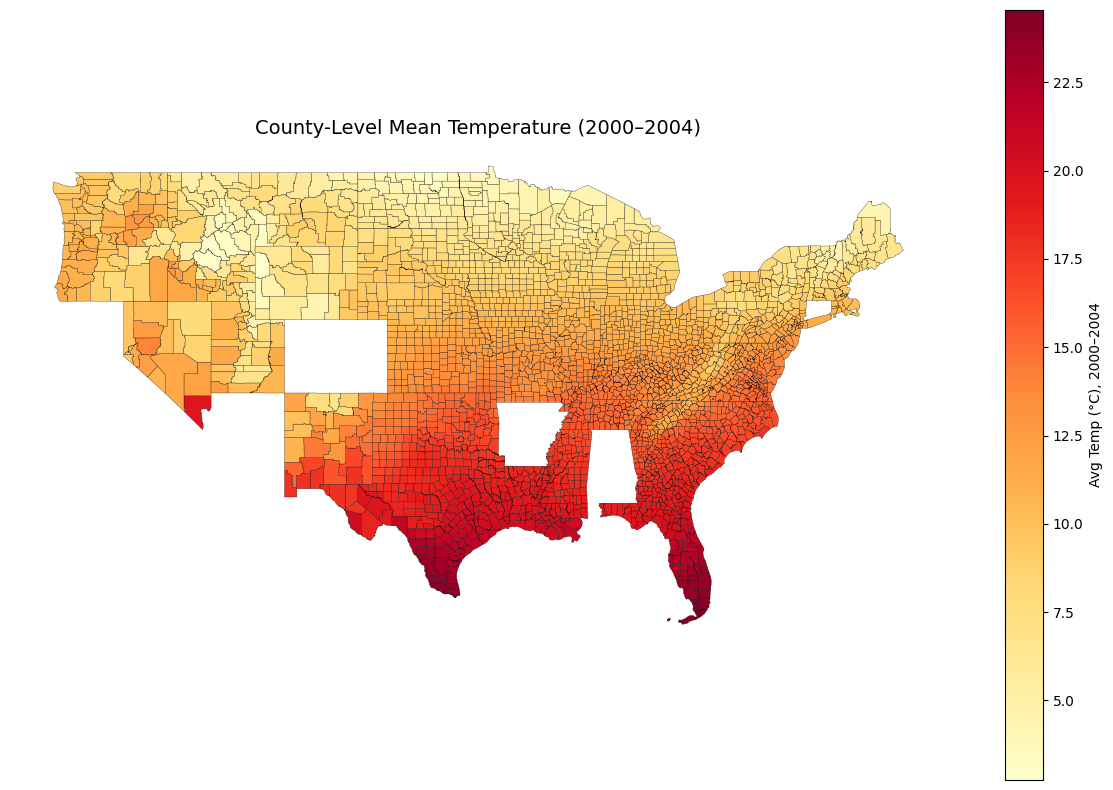

In [20]:
# Filter to years 2000–2004
df_2000_2004 = attribution_output_data[attribution_output_data["year"].between(2000, 2004)]

# Group by county 'poly_id' and compute mean temperature
county_avg_temp = df_2000_2004.groupby("poly_id")["order_1_avg.x"].mean().reset_index()
county_avg_temp.rename(columns={"order_1_avg.x": "mean_temp_00_04"}, inplace=True)

# Convert types to string for merging
county_avg_temp["poly_id"] = county_avg_temp["poly_id"].astype(str)
usa_counties["GEOID"] = usa_counties["GEOID"].astype(str)

# Merge on the correct column
merged = usa_counties.merge(county_avg_temp, left_on="GEOID", right_on="poly_id", how="left")

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
merged.plot(
    column="mean_temp_00_04",
    ax=ax,
    cmap="YlOrRd",
    edgecolor="black",
    linewidth=0.2,
    legend=True,
    legend_kwds={"label": "Avg Temp (°C), 2000–2004"}
)
ax.set_title("County-Level Mean Temperature (2000–2004)", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()


In [21]:
# Group by county (poly_id) and calculate:
# 1. mean ignoring NaNs (default for pandas mean)
# 2. count of NaNs = total count - count of non-NaN values

grouped = attribution_output_data.groupby('poly_id')['order_1_avg.x']

# Mean skipping NaNs
mean_temp = grouped.mean()

# Count total rows per county
total_counts = grouped.size()

# Count non-NaN rows per county
non_na_counts = grouped.count()

# Number of NaNs = total - non-NaN
num_nans = total_counts - non_na_counts

# Combine into a DataFrame
county_stats = pd.DataFrame({
    'mean_temp': mean_temp,
    'num_nans': num_nans
})

county_stats = county_stats.reset_index()


In [23]:
county_stats["poly_id"] = county_stats["poly_id"].astype(str)
usa_counties["GEOID"] = usa_counties["GEOID"].astype(str)
merged = usa_counties.merge(county_stats, left_on='GEOID', right_on='poly_id', how='left')


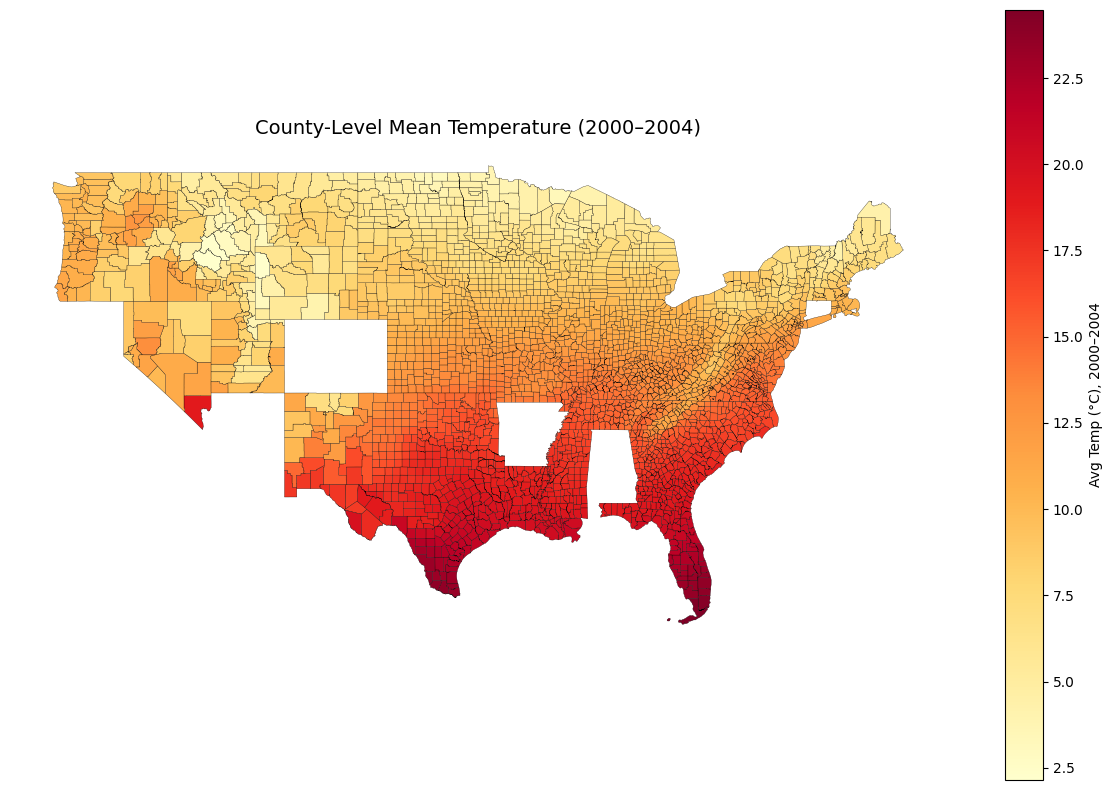

In [25]:

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
merged.plot(
    column="mean_temp",
    ax=ax,
    cmap="YlOrRd",
    edgecolor="black",
    linewidth=0.2,
    legend=True,
    legend_kwds={"label": "Avg Temp (°C), 2000–2004"}
)
ax.set_title("County-Level Mean Temperature (2000–2004)", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()
